In [ ]:
import sys
import os
# Add pipeline directory to sys.path to enable imports
sys.path.append(os.path.abspath('../pipeline'))


# Model Training

### Imports

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


### Dataset Loading

In [2]:
import os
import cv2
import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output
import time

DATASET_ROOT = '../Penn_Action/Penn_Action'
FRAMES_DIR = os.path.join(DATASET_ROOT, 'frames')
LABELS_DIR = os.path.join(DATASET_ROOT, 'labels')

sequence_id = '1734' # The sequence with the "flying" head

mat_path = os.path.join(LABELS_DIR, f'{sequence_id}.mat')
mat_data = sio.loadmat(mat_path)
n_frames = mat_data['nframes'][0][0]

# --- Joint Indices ---
pose_names = ['Head', 'L_Sho', 'R_Sho', 'L_Elb', 'R_Elb', 'L_Wri', 'R_Wri', 
              'L_Hip', 'R_Hip', 'L_Kne', 'R_Kne', 'L_Ank', 'R_Ank']

skeleton = [(0,1), (0,2), (1,3), (3,5), (2,4), (4,6), 
            (1,7), (2,8), (7,8), (7,9), (9,11), (8,10), (10,12)]

# ==========================================
# STEP 1: LOAD ALL FRAMES 
# ==========================================
raw_data = []
for f in range(n_frames):
    jx = mat_data['x'][f].astype(float)
    jy = mat_data['y'][f].astype(float)
    vis = mat_data['visibility'][f]
    
    row = {}
    for i in range(13):
        if vis[i] == 1:
            row[f'{pose_names[i]}_x'] = jx[i]
            row[f'{pose_names[i]}_y'] = jy[i]
        else:
            row[f'{pose_names[i]}_x'] = np.nan
            row[f'{pose_names[i]}_y'] = np.nan
    raw_data.append(row)

df = pd.DataFrame(raw_data)

# ==========================================
# STEP 1.5: FIX THE HEAD (RIGID TORSO LENGTH)
# ==========================================
# 1. Create a stable Mid-Hip point
df['Mid_Hip_x'] = df[['L_Hip_x', 'R_Hip_x']].mean(axis=1)
df['Mid_Hip_y'] = df[['L_Hip_y', 'R_Hip_y']].mean(axis=1)

# 2. Find the "True Torso Length" from frames where both Head and Hip are visible
valid_torso = df.dropna(subset=['Head_y', 'Mid_Hip_y'])
if not valid_torso.empty:
    true_torso_y = (valid_torso['Mid_Hip_y'] - valid_torso['Head_y']).median()
    true_torso_x = (valid_torso['Mid_Hip_x'] - valid_torso['Head_x']).median()
else:
    true_torso_y = 150.0 # Fallback 
    true_torso_x = 0.0

# 3. Reconstruct the missing Head based on the moving Hips!
for f in range(n_frames):
    if pd.isna(df.at[f, 'Head_y']) and not pd.isna(df.at[f, 'Mid_Hip_y']):
        df.at[f, 'Head_y'] = df.at[f, 'Mid_Hip_y'] - true_torso_y
        df.at[f, 'Head_x'] = df.at[f, 'Mid_Hip_x'] - true_torso_x

# Interpolate any remaining tiny gaps for the Head
df['Head_x'] = df['Head_x'].interpolate(method='linear', limit_direction='both')
df['Head_y'] = df['Head_y'].interpolate(method='linear', limit_direction='both')

# ==========================================
# STEP 1.6: SIDE-PROFILE KINEMATICS & SYMMETRY
# ==========================================
for f in range(n_frames):
    head_y, head_x = df.at[f, 'Head_y'], df.at[f, 'Head_x']
    
    # --- ENFORCE L/R SYMMETRY ---
    # If one side is visible but the other is missing, copy it (Left = Right)
    for joint in ['Sho', 'Elb', 'Wri', 'Kne', 'Ank']:
        r_y, r_x = f'R_{joint}_y', f'R_{joint}_x'
        l_y, l_x = f'L_{joint}_y', f'L_{joint}_x'
        
        if not pd.isna(df.at[f, r_y]) and pd.isna(df.at[f, l_y]):
            df.at[f, l_y] = df.at[f, r_y]
            df.at[f, l_x] = df.at[f, r_x]
        elif not pd.isna(df.at[f, l_y]) and pd.isna(df.at[f, r_y]):
            df.at[f, r_y] = df.at[f, l_y]
            df.at[f, r_x] = df.at[f, l_x]

    # --- BUILD MISSING ARMS ---
    # If BOTH shoulders are missing, build them parallel
    if pd.isna(df.at[f, 'R_Sho_y']):
        sho_y = head_y + (true_torso_y * 0.2)
        sho_x = head_x
        df.at[f, 'R_Sho_y'] = df.at[f, 'L_Sho_y'] = sho_y
        df.at[f, 'R_Sho_x'] = df.at[f, 'L_Sho_x'] = sho_x
        
    # If BOTH elbows are missing, build them parallel
    if pd.isna(df.at[f, 'R_Elb_y']):
        elb_y = df.at[f, 'R_Sho_y'] + (true_torso_y * 0.35)
        elb_x = df.at[f, 'R_Sho_x'] - (true_torso_y * 0.2)
        df.at[f, 'R_Elb_y'] = df.at[f, 'L_Elb_y'] = elb_y
        df.at[f, 'R_Elb_x'] = df.at[f, 'L_Elb_x'] = elb_x
        
    # If BOTH wrists are missing, build them parallel
    if pd.isna(df.at[f, 'R_Wri_y']):
        wri_y = df.at[f, 'R_Sho_y'] - (true_torso_y * 0.05)
        wri_x = df.at[f, 'R_Sho_x'] + (true_torso_y * 0.1)
        df.at[f, 'R_Wri_y'] = df.at[f, 'L_Wri_y'] = wri_y
        df.at[f, 'R_Wri_x'] = df.at[f, 'L_Wri_x'] = wri_x

# ==========================================
# STEP 2: ANCHOR-BASED RELATIVE INTERPOLATION
# ==========================================
for name in pose_names[1:]: 
    df[f'{name}_rel_x'] = df[f'{name}_x'] - df['Head_x']
    df[f'{name}_rel_y'] = df[f'{name}_y'] - df['Head_y']

for name in pose_names[1:]:
    df[f'{name}_rel_x'] = df[f'{name}_rel_x'].interpolate(method='linear', limit_direction='both')
    df[f'{name}_rel_y'] = df[f'{name}_rel_y'].interpolate(method='linear', limit_direction='both')

for name in pose_names[1:]:
    df[f'{name}_x'] = df[f'{name}_rel_x'] + df['Head_x']
    df[f'{name}_y'] = df[f'{name}_rel_y'] + df['Head_y']

# ==========================================
# STEP 3: VISUALIZATION PLAYBACK
# ==========================================
for frame_idx in range(n_frames):
    vis = mat_data['visibility'][frame_idx].copy()
    
    joints_x = [df.iloc[frame_idx][f'{name}_x'] for name in pose_names]
    joints_y = [df.iloc[frame_idx][f'{name}_y'] for name in pose_names]

    img_filename = f"{frame_idx + 1:06d}.jpg"
    img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        img_filename = f"{frame_idx + 1:04d}.jpg"
        img_path = os.path.join(FRAMES_DIR, sequence_id, img_filename)
        img = cv2.imread(img_path)
        if img is None: continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    for (j1, j2) in skeleton:
        if not np.isnan(joints_x[j1]) and not np.isnan(joints_x[j2]):
            cv2.line(img, (int(joints_x[j1]), int(joints_y[j1])), 
                     (int(joints_x[j2]), int(joints_y[j2])), (255, 255, 0), 2)

    for i in range(13):
        if not np.isnan(joints_x[i]):
            cx, cy = int(joints_x[i]), int(joints_y[i])
            
            if vis[i] == 0:
                cv2.circle(img, (cx, cy), 6, (255, 0, 0), -1) 
                cv2.putText(img, f"*{pose_names[i]}", (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 100, 100), 1, cv2.LINE_AA)
            else:
                cv2.circle(img, (cx, cy), 5, (0, 255, 0), -1)
                cv2.putText(img, pose_names[i], (cx + 5, cy - 5), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 255, 200), 1, cv2.LINE_AA)
                
    clear_output(wait=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.title(f"Rigid Torso & Symmetry Fix | Seq: {sequence_id} | Frame: {frame_idx+1}/{n_frames}\nGreen = Ground Truth | Red = Predicted")
    plt.axis('off')
    plt.show()
    
    time.sleep(0.1)

FileNotFoundError: [Errno 2] No such file or directory: './Penn_Action/Penn_Action\\labels\\1734.mat'

Once a dataset is preprocessed and feature extracted, add the file to the following dictionary.

In [ ]:
files_and_labels = {
    'normalized/pullup_normalized_summary.csv': 'Pullup',
    'normalized/jump_rope_normalized_summary.csv': 'Jump Rope',
    'normalized/pushup_normalized_summary.csv': 'Pushup',
    'normalized/squat_normalized_summary.csv': 'Squat'
}


Combining in a master dataset.

In [ ]:
dataframes = []
for file_path, label in files_and_labels.items():
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df['Action_Label'] = label  
        dataframes.append(df)
        print(f"Loaded {len(df)} samples for {label}")
    else:
        print(f"Warning: {file_path} not found. Skipping.")

# Combine all into one master dataset
if not dataframes:
    raise ValueError("No data files were loaded. Check your 'normalized' folder path.")
    
master_df = pd.concat(dataframes, ignore_index=True)

Loaded 199 samples for Pullup
Loaded 194 samples for Jump Rope
Loaded 211 samples for Pushup
Loaded 231 samples for Squat


In [ ]:
X = master_df.drop(columns=['Sequence_ID', 'Action_Label'])
y = master_df['Action_Label']

# Handle the categorical 'Pose' column using One-Hot Encoding
X = pd.get_dummies(X, columns=['Pose'], drop_first=False)

# Fill any remaining NaNs (in case some sequences were too short/corrupted)
X = X.fillna(0)

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Random Forest Training

In [ ]:
classifier = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y


--- Classification Report ---
              precision    recall  f1-score   support

   Jump Rope       0.95      1.00      0.97        39
      Pullup       0.97      0.97      0.97        40
      Pushup       1.00      1.00      1.00        42
       Squat       1.00      0.96      0.98        46

    accuracy                           0.98       167
   macro avg       0.98      0.98      0.98       167
weighted avg       0.98      0.98      0.98       167

Overall Accuracy: 98.20%



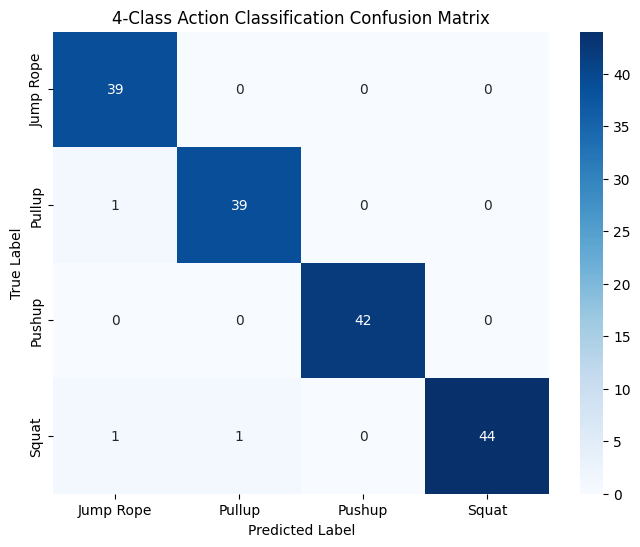

In [ ]:
y_pred = classifier.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.title('4-Class Action Classification Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_9732\3119465939.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


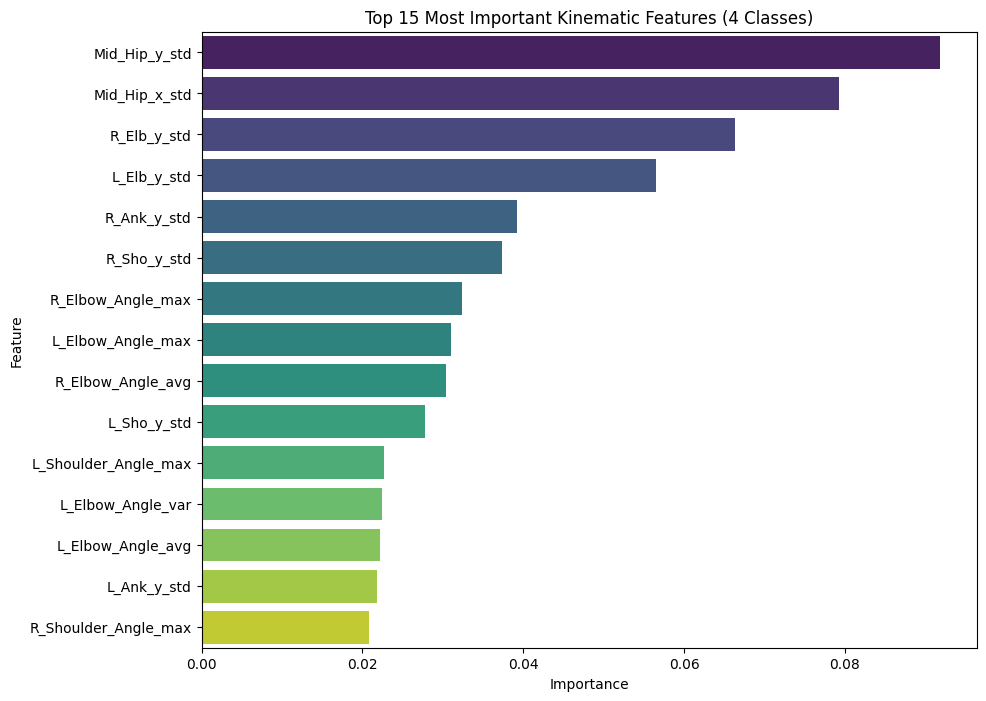

In [ ]:
# ==========================================
# STEP 5: FEATURE IMPORTANCE
# ==========================================
# See which kinematic features the model relies on the most across all 4 classes
importances = classifier.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Top 15 Most Important Kinematic Features (4 Classes)')
plt.show()

### Correlation Matrix Mapping

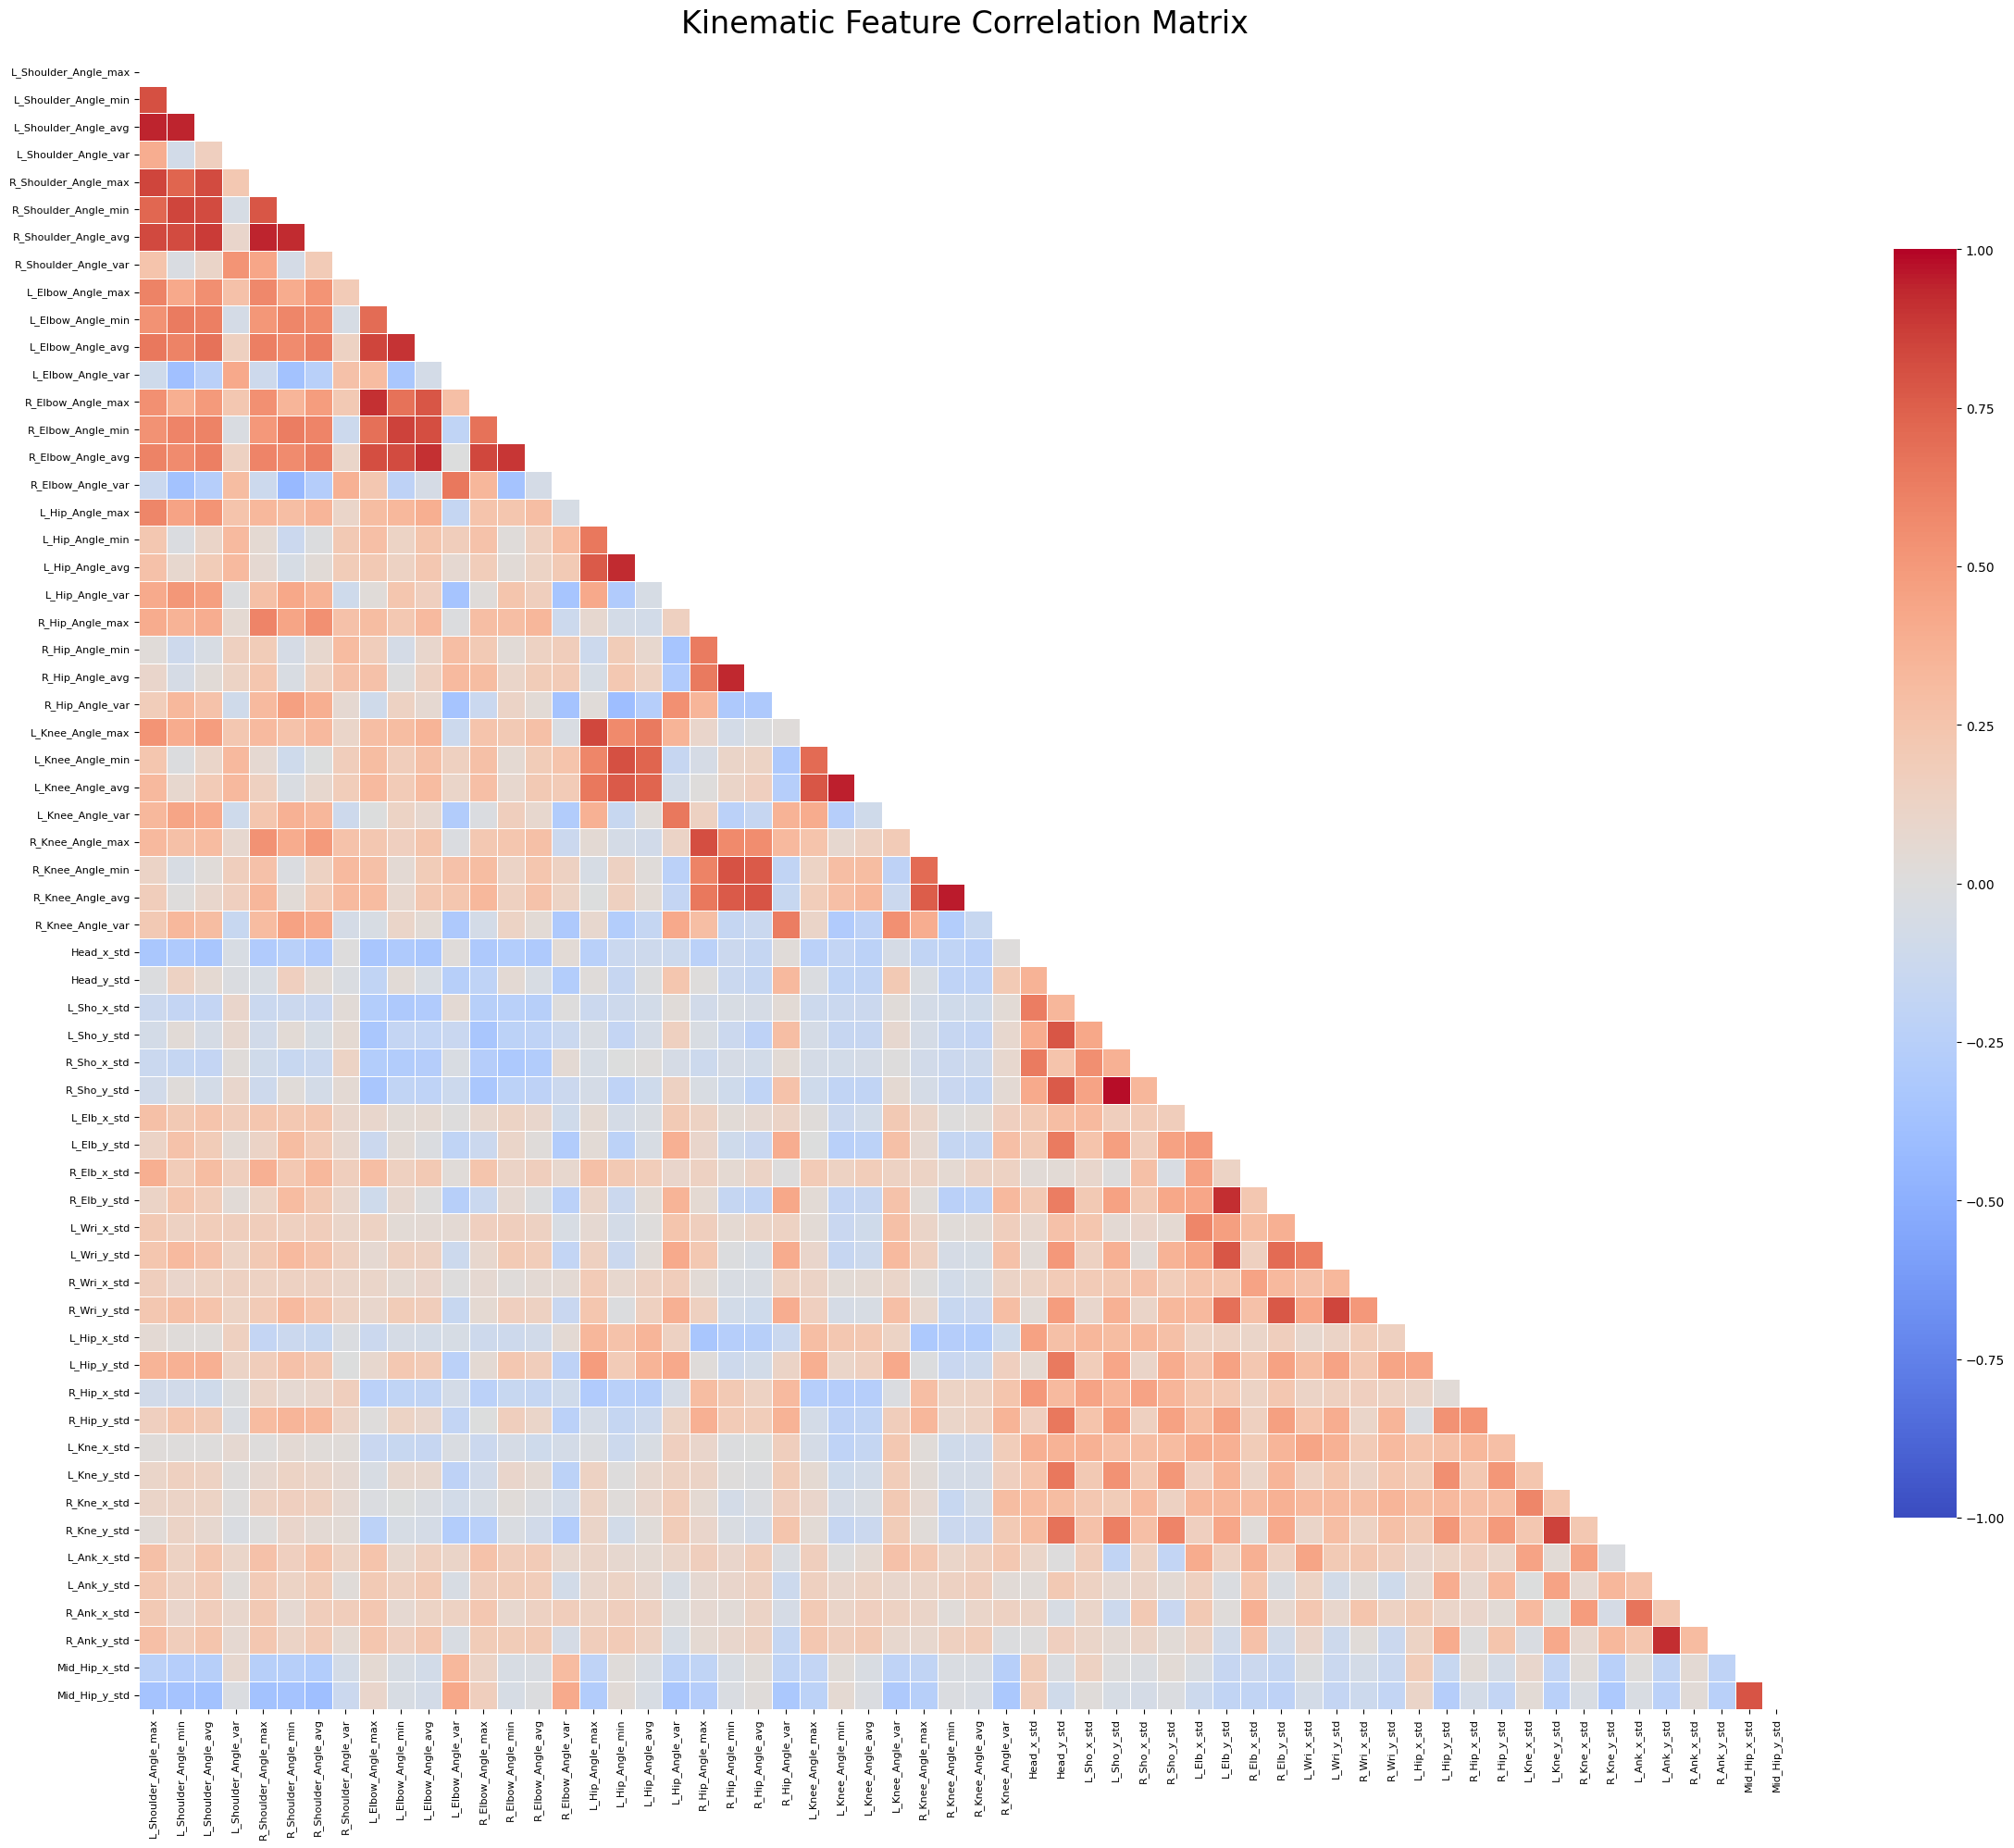

In [ ]:
# Drop non-numeric columns and identifiers
cols_to_drop = ['Sequence_ID', 'Pose', 'Action_Label']
# Only drop them if they exist in the dataframe
cols_to_drop = [col for col in cols_to_drop if col in master_df.columns]

numeric_df = master_df.drop(columns=cols_to_drop)

# Fill NaNs with 0 just in case there are missing values
numeric_df = numeric_df.fillna(0)

# Compute the correlation matrix
corr_matrix = numeric_df.corr()


# We need a very large figure size because you have ~50+ features
plt.figure(figsize=(24, 20))

# Generate a mask for the upper triangle so we don't show duplicate info (optional but cleaner)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm',  # Red for positive correlation, Blue for negative
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .75},
    annot=False # Set to True if you want the actual numbers, but it will be very cluttered!
)

plt.title('Kinematic Feature Correlation Matrix', fontsize=24, pad=20)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()

# Save the high-res image so you can zoom in and investigate it!
plt.savefig('kinematic_correlation_matrix.png', dpi=300)
plt.show()

## PCA Analysis


--- Highly Correlated Features Removed (> 0.9 correlation) ---
- L_Shoulder_Angle_avg
- R_Shoulder_Angle_avg
- R_Elbow_Angle_max
- R_Elbow_Angle_avg
- L_Hip_Angle_avg
- R_Hip_Angle_avg
- L_Knee_Angle_avg
- R_Knee_Angle_avg
- R_Sho_y_std
- R_Elb_y_std
- R_Ank_y_std
- Pose_Side

Features remaining after dropping correlated ones: 50 (Started with 62)

--- PCA Summary ---
Features entering PCA: 50
Principal Components kept (retaining 95% of information): 28
Total dimensions effectively removed: 34


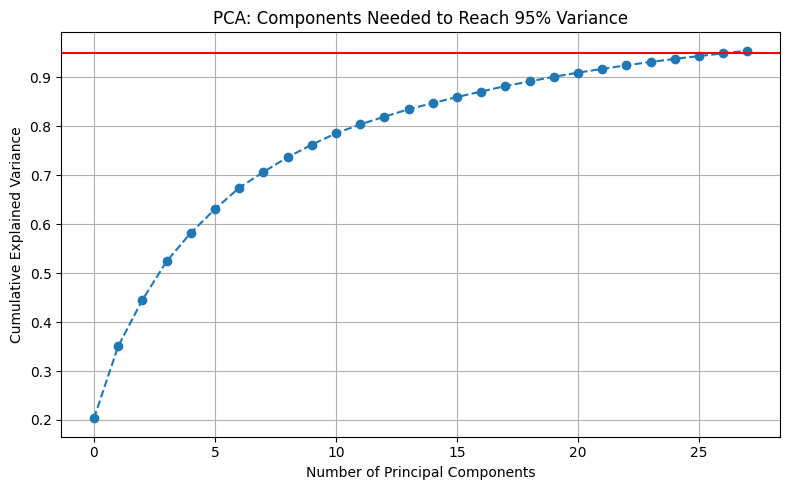

In [ ]:
# Calculate absolute correlation matrix
corr_matrix = X.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.90
threshold = 0.90
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print(f"\n--- Highly Correlated Features Removed (> {threshold} correlation) ---")
for feature in to_drop:
    print(f"- {feature}")

# Drop them from our dataset
X_reduced = X.drop(columns=to_drop)
print(f"\nFeatures remaining after dropping correlated ones: {X_reduced.shape[1]} (Started with {X.shape[1]})")

# PCA works best when data is standardized (mean=0, variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)

# Initialize PCA to keep 95% of the dataset's variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"\n--- PCA Summary ---")
print(f"Features entering PCA: {X_reduced.shape[1]}")
print(f"Principal Components kept (retaining 95% of information): {pca.n_components_}")
print(f"Total dimensions effectively removed: {X.shape[1] - pca.n_components_}")
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Components Needed to Reach 95% Variance')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
X = master_df.drop(columns=['Sequence_ID', 'Action_Label'])
y = master_df['Action_Label']

# Handle the categorical 'Pose' column using One-Hot Encoding
X = pd.get_dummies(X, columns=['Pose'], drop_first=False).fillna(0)

# SPLIT FIRST to prevent data leakage!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nData Split: Training on {len(X_train)} samples, Testing on {len(X_test)} samples.")


Data Split: Training on 668 samples, Testing on 167 samples.


In [ ]:
# Identify highly correlated features strictly on the training set
corr_matrix = X_train.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

# Drop them from both train and test sets
X_train_reduced = X_train.drop(columns=to_drop)
X_test_reduced = X_test.drop(columns=to_drop)

In [ ]:
# 1. Scale the data (Mean=0, Variance=1) - Required for PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced) # Transform test using train's rules

# 2. Apply PCA (Retain 95% variance)
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled) # Transform test using train's rules

print(f"Final training dimensions after PCA: {X_train_pca.shape[1]}")

Final training dimensions after PCA: 28


In [ ]:
clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
clf.fit(X_train_pca, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y


--- Final Classification Report ---
              precision    recall  f1-score   support

   Jump Rope       0.95      0.92      0.94        39
      Pullup       0.86      0.93      0.89        40
      Pushup       0.98      0.95      0.96        42
       Squat       0.93      0.91      0.92        46

    accuracy                           0.93       167
   macro avg       0.93      0.93      0.93       167
weighted avg       0.93      0.93      0.93       167

Overall Accuracy: 92.81%



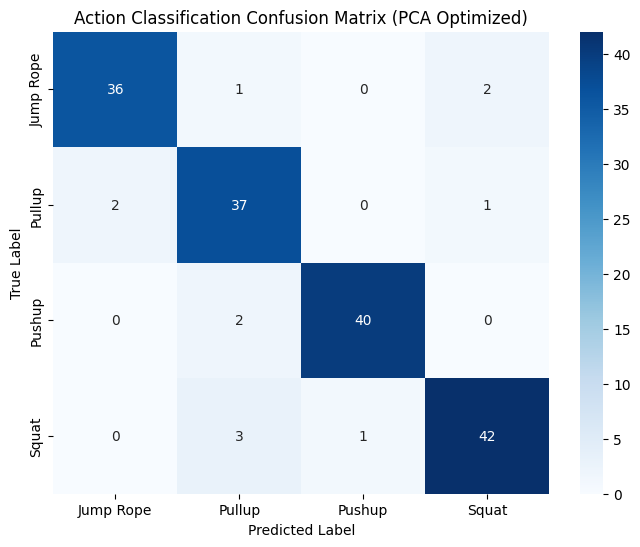

In [ ]:
y_pred = clf.predict(X_test_pca)

print("\n--- Final Classification Report ---")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title('Action Classification Confusion Matrix (PCA Optimized)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42)
svm_model.fit(X_train_pca, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False



--- Final SVM Classification Report ---
              precision    recall  f1-score   support

   Jump Rope       0.97      0.95      0.96        39
      Pullup       0.89      1.00      0.94        40
      Pushup       0.98      0.95      0.96        42
       Squat       1.00      0.93      0.97        46

    accuracy                           0.96       167
   macro avg       0.96      0.96      0.96       167
weighted avg       0.96      0.96      0.96       167

Overall Accuracy: 95.81%



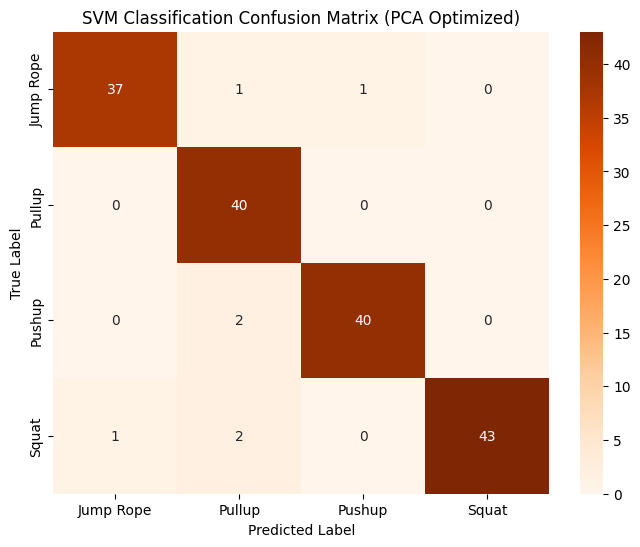

In [ ]:
y_pred = svm_model.predict(X_test_pca)

print("\n--- Final SVM Classification Report ---")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.title('SVM Classification Confusion Matrix (PCA Optimized)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# ── SAVE CLASSIFIER BUNDLE ──────────────────────────────────────────────────
import pickle

classifier_bundle = {
    'rf_model'        : clf,
    'svm_model'       : svm_model,
    'scaler'          : scaler,
    'pca'             : pca,
    'cols_to_drop'    : to_drop,
    'feature_columns' : list(X_train_reduced.columns),
    'classes'         : list(clf.classes_),
}

with open('classifier.pkl', 'wb') as f:
    pickle.dump(classifier_bundle, f)

print('Saved classifier.pkl')
print(f'  Classes  : {classifier_bundle["classes"]}')
print(f'  Features : {len(classifier_bundle["feature_columns"])}')
print(f'  PCA dims : {pca.n_components_}')